# U.S. Treasury Yield Curve vs. Gold (XAU/USD)

This notebook studies the contemporaneous and time-varying relationship between daily U.S. Treasury yield changes and gold log returns, then extends the analysis toward real Treasury yields.

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.linear_model import LinearRegression

# Mathematical Theory

## Bond Price

The **bond price** is the present value of the bond's remaining coupon payments plus the present value of the face value that will be repaid at maturity.

The bond-pricing function takes the following inputs:

* `fv` — Face value of the bond.
* `c` — Annual coupon rate.
* `ytm` — Annualized yield to maturity.
* `n` — Number of remaining coupon-payment periods.
* `periods_per_year` — Number of coupon payments made each year.

The function first determines the coupon payment made during each period:

$$
C = \frac{fv \cdot c}{m}
$$

It then determines the yield applicable to each period:

$$
y = \frac{ytm}{m}
$$

The bond's price is calculated by discounting all future coupon payments and the final face-value payment back to the present:

$$
P =
\sum_{t=1}^{n}
\frac{C}{(1+y)^t}
+
\frac{fv}{(1+y)^n}
$$

In simple terms:

**Bond Price = Present Value of Coupon Payments + Present Value of Face Value**

The function returns the estimated current price of the bond.


In [2]:
def bond_price(fv, c, ytm, n, periods_per_year):
    C = fv * c / periods_per_year  
    y = ytm / periods_per_year  
    t = np.arange(1,n + 1) 
    coupon_payments = np.sum(C / (1 + y) ** t) 
    face_payments = fv /( 1 + y ) ** n 
    return coupon_payments  + face_payments

## Macaulay Duration

**Macaulay duration** measures the weighted average amount of time required to receive a bond's cash flows.

The Macaulay duration function takes the following inputs:

* `face` — Face value of the bond.
* `coupon_rate` — Annual coupon rate.
* `ytm` — Annualized yield to maturity.
* `n_periods` — Number of remaining coupon-payment periods.
* `periods_per_year` — Number of coupon payments made each year.

The function first calculates the coupon payment per period:

$$
C = \frac{face \cdot coupon_rate}{periods_per_year}
$$

The yield per period is:

$$
y = \frac{ytm}{periods_per_year}
$$

Each future cash flow is discounted to determine its present value:

$$
PV_t = \frac{CF_t}{(1+y)^t}
$$

The final cash flow includes both the final coupon payment and the repayment of the bond's face value.

The bond price is the sum of the present values of all remaining cash flows:

$$
P = \sum_{t=1}^{n} PV_t
$$

Macaulay duration is then calculated as:

$$
D_M =
\frac{
\sum_{t=1}^{n}
\left(\frac{t}{m}\right)PV_t
}{
P
}
$$

where:

* $D_M$ — Macaulay duration in years.
* $t$ — Current payment period.
* $m$ — Number of payment periods per year.
* $PV_t$ — Present value of the cash flow received during period $t$.
* $P$ — Current bond price.

In simple terms:

**Macaulay Duration = Present-value-weighted average time until the bond's cash flows are received.**

The function returns the bond's Macaulay duration measured in **years**.


In [3]:
def macaulay_duration_scratch(face, coupon_rate, ytm, n_periods, periods_per_year=1):
    c = face * coupon_rate / periods_per_year
    y = ytm / periods_per_year
    t = np.arange(1, n_periods + 1)
    cash_flows = np.full(n_periods, c, dtype=float)
    cash_flows[-1] += face
    pv = cash_flows / (1 + y) ** t
    price = pv.sum()
    weighted = np.sum((t / periods_per_year) * pv)
    return weighted / price

## Bond Convexity

**Convexity** measures the curvature of the relationship between a bond's price and its yield to maturity.

Bond prices and yields have an inverse relationship:

$$
y \uparrow \quad \Rightarrow \quad P \downarrow
$$

$$
y \downarrow \quad \Rightarrow \quad P \uparrow
$$

However, this relationship is not perfectly linear. Bond prices change along a curve as yields change.

### Duration and Convexity

**Duration** measures the first-order sensitivity of a bond's price to changes in yield.

Modified duration gives the approximation:

$$
\frac{\Delta P}{P}
\approx
-D_{mod}\Delta y
$$

where:

* $P$ = current bond price
* $\Delta P$ = change in bond price
* $D_{mod}$ = modified duration
* $\Delta y$ = change in yield

Duration can therefore be thought of as measuring the **slope** of the bond's price-yield relationship.

**Convexity** measures how that slope changes as the yield changes.

Conceptually:

**Duration = Slope**

**Convexity = Curvature**

### Mathematical Definition

Convexity is related to the second derivative of bond price with respect to yield:

$$
Convexity =
\frac{1}{P}
\frac{d^2P}{dy^2}
$$

The second derivative measures how the bond's price sensitivity changes as its yield changes.

### Duration-Convexity Approximation

Duration and convexity can be combined to provide a better approximation of a bond's price change:

$$
\frac{\Delta P}{P}
\approx
-D_{mod}\Delta y
+
\frac{1}{2}Convexity(\Delta y)^2
$$

The duration component provides the linear approximation:

$$
-D_{mod}\Delta y
$$

while the convexity component corrects for the curvature:

$$
\frac{1}{2}Convexity(\Delta y)^2
$$

### Interpretation

For relatively small changes in yield, duration may provide a reasonable estimate of the bond's price movement.

For larger changes in yield, convexity becomes increasingly important because the relationship between bond prices and yields is curved rather than linear.

For a standard option-free bond, convexity is generally positive.

In simple terms:

**Convexity = A measure of how much the bond's price-yield relationship bends.**


In [4]:
def convexity(face, coupon_rate, ytm, n_periods, periods_per_year=1):
    c = face * coupon_rate / periods_per_year
    y = ytm / periods_per_year
    t = np.arange(1, n_periods + 1)
    cash_flows = np.full(n_periods, c, dtype=float)
    cash_flows[-1] += face
    pv = cash_flows / (1 + y) ** t
    price = pv.sum()
    total = np.sum((t / periods_per_year) * (t / periods_per_year + 1 / periods_per_year) * pv)
    return (total / (price * (1 + y) ** 2)) / (periods_per_year ** 2)

## 2. Load and Clean Nominal U.S. Treasury Yields

In [5]:
working_directory = os.listdir()
csv_list = [file for file in working_directory if file.endswith(".csv")]
print(csv_list)

dataframes = {}
for file in csv_list:
    df = pd.read_csv(file)
    name = os.path.splitext(file)[0]
    dataframes[name] = df

for name, df in dataframes.items():
    if "observation_date" in df.columns:
        df["observation_date"] = pd.to_datetime(df["observation_date"])
        df = df.set_index("observation_date")
        dataframes[name] = df.loc["2023-01-01":].copy()

['DGS1.csv', 'DGS10.csv', 'DGS2.csv', 'DGS20.csv', 'DGS3.csv', 'DGS30.csv', 'DGS3MO.csv', 'DGS5.csv', 'DGS6MO.csv', 'DGS7.csv', 'fredgraph.csv', 'XAU_USD Historical Data.csv']


In [6]:
treasury_series = [
    "DGS3MO", "DGS6MO", "DGS1", "DGS2", "DGS3",
    "DGS5", "DGS7", "DGS10", "DGS20", "DGS30"
]

Treasury_Yields = pd.concat(
    [dataframes[ticker] for ticker in treasury_series],
    axis=1
)

print("Missing values before cleaning:")
print(Treasury_Yields.isna().sum())

Treasury_Yields = Treasury_Yields.dropna()
Treasury_Yields.head(20)

Missing values before cleaning:
DGS3MO    40
DGS6MO    40
DGS1      40
DGS2      40
DGS3      40
DGS5      40
DGS7      40
DGS10     40
DGS20     40
DGS30     40
dtype: int64


,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
observation_date,,,,,,,,,,
2023-01-03,4.53,4.77,4.72,4.40,4.18,3.94,3.89,3.79,4.06,3.88
2023-01-04,4.55,4.77,4.71,4.36,4.11,3.85,3.79,3.69,3.97,3.81
2023-01-05,4.66,4.81,4.78,4.45,4.18,3.90,3.82,3.71,3.96,3.78
2023-01-06,4.67,4.79,4.71,4.24,3.96,3.69,3.63,3.55,3.84,3.67
2023-01-09,4.70,4.83,4.69,4.19,3.93,3.66,3.60,3.53,3.83,3.66
2023-01-10,4.73,4.85,4.74,4.24,3.94,3.72,3.67,3.61,3.91,3.74
2023-01-11,4.72,4.84,4.73,4.20,3.90,3.66,3.61,3.54,3.84,3.67
2023-01-12,4.66,4.76,4.66,4.12,3.79,3.53,3.48,3.43,3.73,3.56
2023-01-13,4.67,4.77,4.69,4.22,3.88,3.60,3.55,3.49,3.79,3.61


In [7]:
print("Shape:", Treasury_Yields.shape)
print("\nData types:")
print(Treasury_Yields.dtypes)

Treasury_Yields.describe()

Shape: (901, 10)

Data types:
DGS3MO    float64
DGS6MO    float64
DGS1      float64
DGS2      float64
DGS3      float64
DGS5      float64
DGS7      float64
DGS10     float64
DGS20     float64
DGS30     float64
dtype: object


,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
count,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000
mean,4.696160,4.619789,4.424095,4.189057,4.073862,4.031032,4.108579,4.189356,4.581165,4.511498
std,0.682785,0.672805,0.620049,0.474586,0.393694,0.327645,0.313575,0.325939,0.364571,0.408676
min,3.620000,3.560000,3.400000,3.380000,3.390000,3.290000,3.320000,3.300000,3.650000,3.540000
25%,4.060000,4.000000,3.920000,3.820000,3.750000,3.750000,3.900000,4.020000,4.370000,4.260000
50%,4.670000,4.440000,4.250000,4.140000,4.050000,4.020000,4.120000,4.240000,4.650000,4.600000
75%,5.440000,5.340000,5.020000,4.600000,4.360000,4.270000,4.330000,4.420000,4.860000,4.840000
max,5.630000,5.610000,5.490000,5.190000,5.030000,4.950000,5.000000,4.980000,5.300000,5.270000


## 3. Load and Clean XAU/USD Data

In [8]:
XAUUSD = pd.read_csv("XAU_USD Historical Data.csv")

XAUUSD["Date"] = pd.to_datetime(XAUUSD["Date"])
XAUUSD = XAUUSD.set_index("Date")
XAUUSD = XAUUSD.sort_index()

XAUUSD = XAUUSD.drop(columns=["Vol."], errors="ignore")
XAUUSD = XAUUSD.loc["2023-01-03":"2026-08-10"]
XAUUSD = XAUUSD.dropna()

XAUUSD.head(10)

,Price,Open,High,Low,Change %
Date,,,,,
2023-01-03,"1,839.49","1,826.14","1,850.69","1,824.42",0.87%
2023-01-04,"1,854.09","1,839.51","1,865.49","1,835.92",0.79%
2023-01-05,"1,833.19","1,854.19","1,859.36","1,824.68",-1.13%
2023-01-06,"1,865.71","1,833.27","1,870.37","1,830.53",1.77%
2023-01-09,"1,871.59","1,865.45","1,881.80","1,864.59",0.32%
2023-01-10,"1,877.27","1,871.66","1,881.04","1,867.37",0.30%
2023-01-11,"1,876.38","1,877.30","1,887.09","1,866.75",-0.05%
2023-01-12,"1,896.86","1,876.43","1,901.88","1,873.64",1.09%
2023-01-13,"1,920.21","1,897.03","1,922.24","1,891.80",1.23%


In [9]:
print("Shape:", XAUUSD.shape)
print("\nData types:")
print(XAUUSD.dtypes)

XAUUSD.describe()

Shape: (935, 5)

Data types:
Price       object
Open        object
High        object
Low         object
Change %    object
dtype: object


,Price,Open,High,Low,Change %
count,935,935,935,935,935
unique,930,931,929,928,394
top,"1,919.57","2,378.60","3,334.21","1,978.90",0.25%
freq,2,2,2,2,12


## 4. Merge Treasury and Gold Data

In [10]:
market_data = Treasury_Yields.join(XAUUSD, how="inner")

market_data = market_data.drop(columns=["Change %"], errors="ignore")

numeric_columns = ["Price", "Open", "High", "Low"]
market_data[numeric_columns] = (
    market_data[numeric_columns]
    .replace(",", "", regex=True)
    .astype(float)
)

market_data.head()

,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30,Price,Open,High,Low
2023-01-03,4.53,4.77,4.72,4.40,4.18,3.94,3.89,3.79,4.06,3.88,1839.49,1826.14,1850.69,1824.42
2023-01-04,4.55,4.77,4.71,4.36,4.11,3.85,3.79,3.69,3.97,3.81,1854.09,1839.51,1865.49,1835.92
2023-01-05,4.66,4.81,4.78,4.45,4.18,3.90,3.82,3.71,3.96,3.78,1833.19,1854.19,1859.36,1824.68
2023-01-06,4.67,4.79,4.71,4.24,3.96,3.69,3.63,3.55,3.84,3.67,1865.71,1833.27,1870.37,1830.53
2023-01-09,4.70,4.83,4.69,4.19,3.93,3.66,3.60,3.53,3.83,3.66,1871.59,1865.45,1881.80,1864.59


## 5. Construct Gold Returns and Daily Yield Changes

In [11]:
market_data["Log Return"] = np.log(
    market_data["Price"] / market_data["Price"].shift(1)
)

yield_columns = [
    "DGS3MO", "DGS6MO", "DGS1", "DGS2", "DGS3",
    "DGS5", "DGS7", "DGS10", "DGS20", "DGS30"
]

for ticker in yield_columns:
    index = market_data.columns.get_loc(ticker) + 1
    market_data.insert(
        index,
        f"{ticker} change",
        market_data[ticker] - market_data[ticker].shift(1)
    )

yield_changes = [f"{ticker} change" for ticker in yield_columns]
market_data = market_data.dropna()
market_data.head()

,DGS3MO,DGS3MO change,DGS6MO,DGS6MO change,DGS1,DGS1 change,DGS2,DGS2 change,DGS3,DGS3 change,...,DGS10 change,DGS20,DGS20 change,DGS30,DGS30 change,Price,Open,High,Low,Log Return
2023-01-04,4.55,0.02,4.77,0.00,4.71,-0.01,4.36,-0.04,4.11,-0.07,...,-0.10,3.97,-0.09,3.81,-0.07,1854.09,1839.51,1865.49,1835.92,0.007906
2023-01-05,4.66,0.11,4.81,0.04,4.78,0.07,4.45,0.09,4.18,0.07,...,0.02,3.96,-0.01,3.78,-0.03,1833.19,1854.19,1859.36,1824.68,-0.011336
2023-01-06,4.67,0.01,4.79,-0.02,4.71,-0.07,4.24,-0.21,3.96,-0.22,...,-0.16,3.84,-0.12,3.67,-0.11,1865.71,1833.27,1870.37,1830.53,0.017584
2023-01-09,4.70,0.03,4.83,0.04,4.69,-0.02,4.19,-0.05,3.93,-0.03,...,-0.02,3.83,-0.01,3.66,-0.01,1871.59,1865.45,1881.80,1864.59,0.003147
2023-01-10,4.73,0.03,4.85,0.02,4.74,0.05,4.24,0.05,3.94,0.01,...,0.08,3.91,0.08,3.74,0.08,1877.27,1871.66,1881.04,1867.37,0.003030


## 6. Full-Sample Pearson Correlations Across the Yield Curve

In [12]:
correlation = {}

for column in yield_changes:
    score = pearsonr(
        market_data[column],
        market_data["Log Return"]
    )
    correlation[column] = {
        "Pearson r": score.statistic,
        "p-value": score.pvalue
    }

correlation_df = pd.DataFrame.from_dict(correlation, orient="index")
correlation_df

,Pearson r,p-value
DGS3MO change,-0.132498,6.754526e-05
DGS6MO change,-0.235467,8.611682e-13
DGS1 change,-0.286544,1.884319e-18
DGS2 change,-0.300870,2.887401e-20
DGS3 change,-0.306487,5.255930e-21
DGS5 change,-0.282960,5.165636e-18
DGS7 change,-0.267062,3.803828e-16
DGS10 change,-0.247851,4.736294e-14
DGS20 change,-0.186336,1.817284e-08
DGS30 change,-0.156612,2.377598e-06


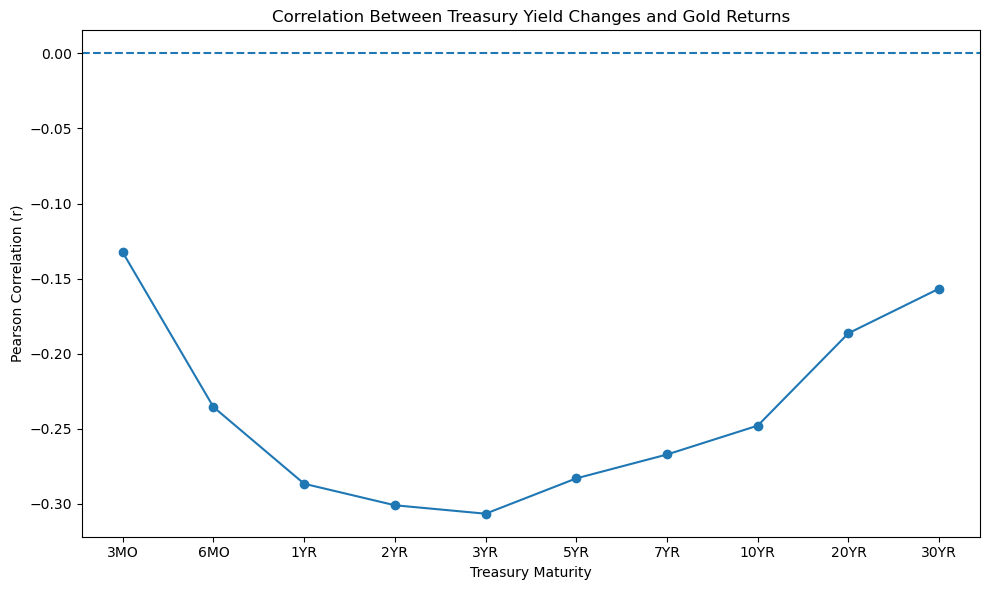

In [13]:
maturities = ["3MO", "6MO", "1YR", "2YR", "3YR", "5YR", "7YR", "10YR", "20YR", "30YR"]

plt.figure(figsize=(10, 6))
plt.plot(maturities, correlation_df["Pearson r"], marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Treasury Maturity")
plt.ylabel("Pearson Correlation (r)")
plt.title("Correlation Between Treasury Yield Changes and Gold Returns")
plt.tight_layout()
plt.show()

## 7. Scatterplot: 3-Year Treasury Yield Changes vs. Gold Returns

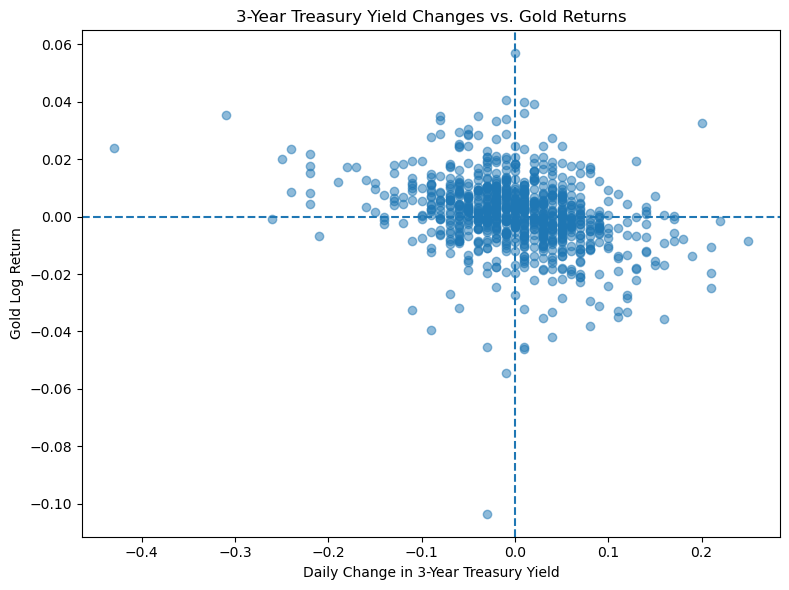

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(
    market_data["DGS3 change"],
    market_data["Log Return"],
    alpha=0.5
)
plt.xlabel("Daily Change in 3-Year Treasury Yield")
plt.ylabel("Gold Log Return")
plt.title("3-Year Treasury Yield Changes vs. Gold Returns")
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.tight_layout()
plt.show()

## 8. 60-Day Rolling Correlation: 3-Year Treasury vs. Gold

In [15]:
rolling_3y_corr = (
    market_data["DGS3 change"]
    .rolling(window=60)
    .corr(market_data["Log Return"])
)

rolling_3y_corr.dropna().head(30)

2023-03-30   -0.731386
2023-03-31   -0.720559
2023-04-03   -0.720995
2023-04-04   -0.713828
2023-04-05   -0.712187
2023-04-06   -0.713504
2023-04-10   -0.720082
2023-04-11   -0.713561
2023-04-12   -0.738943
2023-04-13   -0.732526
2023-04-14   -0.752068
2023-04-17   -0.770605
2023-04-18   -0.769391
2023-04-19   -0.772367
2023-04-20   -0.772920
2023-04-21   -0.768498
2023-04-24   -0.769459
2023-04-25   -0.759996
2023-04-26   -0.760027
2023-04-27   -0.751103
2023-04-28   -0.744567
2023-05-01   -0.768744
2023-05-02   -0.765753
2023-05-03   -0.775446
2023-05-04   -0.776852
2023-05-05   -0.784416
2023-05-08   -0.779425
2023-05-09   -0.780249
2023-05-10   -0.769708
2023-05-11   -0.771146
dtype: float64

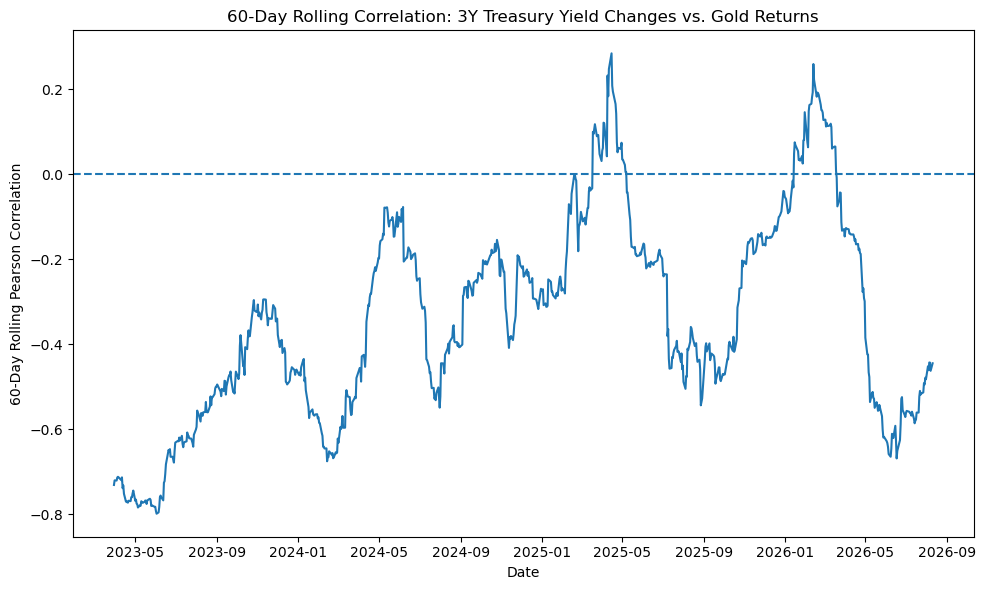

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(rolling_3y_corr.index, rolling_3y_corr)
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("60-Day Rolling Pearson Correlation")
plt.title("60-Day Rolling Correlation: 3Y Treasury Yield Changes vs. Gold Returns")
plt.tight_layout()
plt.show()

## 9. Cross-Maturity 60-Day Rolling Correlations

In [17]:
rolling_corrs = {
    "3M": market_data["DGS3MO change"].rolling(window=60).corr(market_data["Log Return"]),
    "3Y": market_data["DGS3 change"].rolling(window=60).corr(market_data["Log Return"]),
    "10Y": market_data["DGS10 change"].rolling(window=60).corr(market_data["Log Return"]),
    "30Y": market_data["DGS30 change"].rolling(window=60).corr(market_data["Log Return"])
}

rolling_corrs = {
    maturity: corr.dropna()
    for maturity, corr in rolling_corrs.items()
}

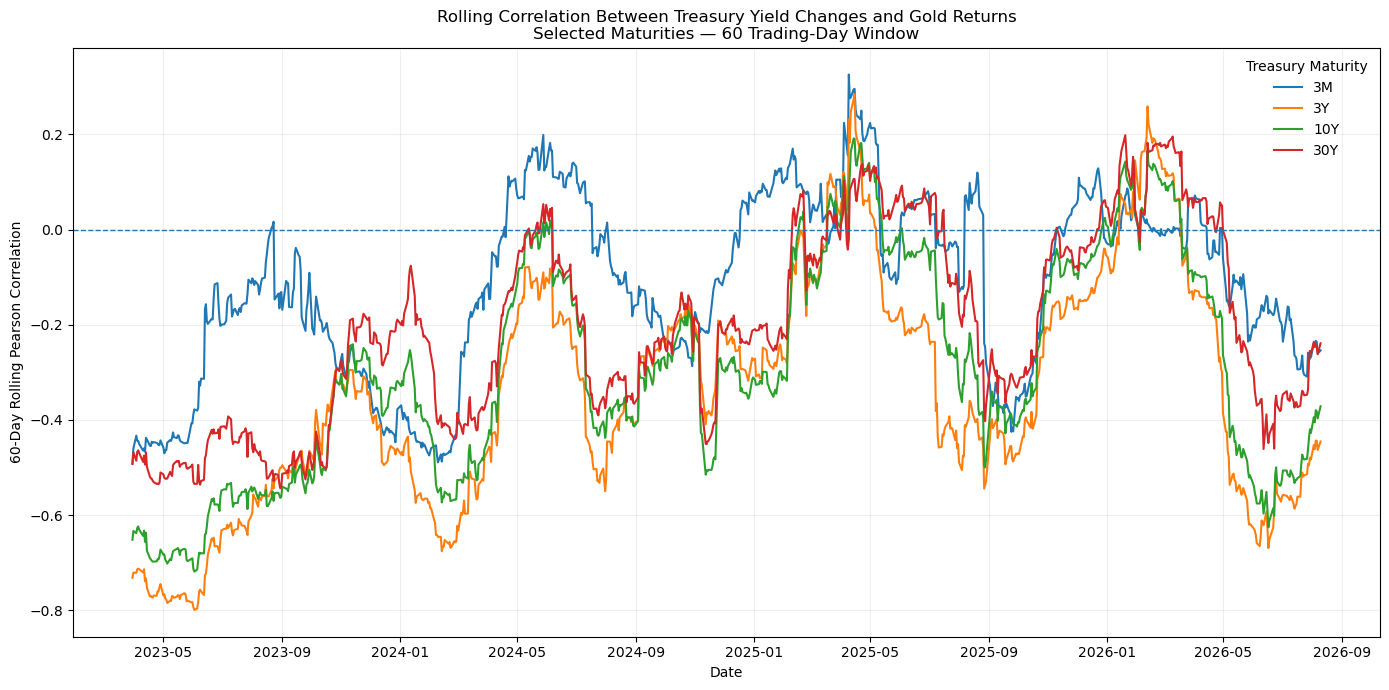

In [18]:
plt.figure(figsize=(14, 7))

for maturity, corr in rolling_corrs.items():
    plt.plot(
        corr.index,
        corr,
        label=maturity,
        linewidth=1.5
    )

plt.axhline(y=0, linestyle="--", linewidth=1)
plt.xlabel("Date")
plt.ylabel("60-Day Rolling Pearson Correlation")
plt.title(
    "Rolling Correlation Between Treasury Yield Changes and Gold Returns\n"
    "Selected Maturities — 60 Trading-Day Window"
)
plt.legend(title="Treasury Maturity", frameon=False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 10. Load and Clean Real Treasury Yields (FRED/TIPS)

This section introduces daily real Treasury yields derived from inflation-indexed Treasury securities. The purpose is to compare the gold relationship with nominal yields against the corresponding relationship with real yields.


In [19]:
fred_graph = pd.read_csv("fredgraph.csv")

fred_graph["observation_date"] = pd.to_datetime(fred_graph["observation_date"])
fred_graph = fred_graph.set_index("observation_date")

print("Missing values before cleaning:")
print(fred_graph.isna().sum())

fred_graph = fred_graph.dropna()

print("\nMissing values after cleaning:")
print(fred_graph.isna().sum())
fred_graph.head()


Missing values before cleaning:
DFII10    60
DFII5     60
DFII20    60
DFII30    60
dtype: int64

Missing values after cleaning:
DFII10    0
DFII5     0
DFII20    0
DFII30    0
dtype: int64


,DFII10,DFII5,DFII20,DFII30
observation_date,,,,
2021-01-04,-1.08,-1.62,-0.63,-0.39
2021-01-05,-1.07,-1.63,-0.61,-0.36
2021-01-06,-1.02,-1.61,-0.55,-0.30
2021-01-07,-1.01,-1.63,-0.53,-0.28
2021-01-08,-0.93,-1.58,-0.46,-0.21


## 11. Merge Real Yields Into the Market Dataset

An inner join keeps only dates observed in both the existing nominal-yield/gold dataset and the real-yield dataset, allowing direct comparisons on a common sample.


In [20]:
market_data = market_data.join(fred_graph, how="inner")

real_yield_columns = ["DFII5", "DFII10", "DFII20", "DFII30"]
print(market_data[real_yield_columns].head())
print("\nMissing real-yield observations after join:")
print(market_data[real_yield_columns].isna().sum())


            DFII5  DFII10  DFII20  DFII30
2023-01-04   1.64    1.47    1.51    1.57
2023-01-05   1.68    1.49    1.50    1.55
2023-01-06   1.51    1.34    1.37    1.43
2023-01-09   1.48    1.31    1.35    1.41
2023-01-10   1.52    1.37    1.41    1.47

Missing real-yield observations after join:
DFII5     0
DFII10    0
DFII20    0
DFII30    0
dtype: int64


## 12. Construct Daily Real-Yield Changes


In [21]:
real_yield_columns = ["DFII5", "DFII10", "DFII20", "DFII30"]

for ticker in real_yield_columns:
    change_name = f"{ticker} change"
    market_data[change_name] = market_data[ticker] - market_data[ticker].shift(1)

market_data = market_data.dropna()

market_data[[
    "DFII5", "DFII5 change",
    "DFII10", "DFII10 change",
    "DFII20", "DFII20 change",
    "DFII30", "DFII30 change"
]].head()


,DFII5,DFII5 change,DFII10,DFII10 change,DFII20,DFII20 change,DFII30,DFII30 change
2023-01-05,1.68,0.04,1.49,0.02,1.50,-0.01,1.55,-0.02
2023-01-06,1.51,-0.17,1.34,-0.15,1.37,-0.13,1.43,-0.12
2023-01-09,1.48,-0.03,1.31,-0.03,1.35,-0.02,1.41,-0.02
2023-01-10,1.52,0.04,1.37,0.06,1.41,0.06,1.47,0.06
2023-01-11,1.45,-0.07,1.31,-0.06,1.35,-0.06,1.41,-0.06


## 13. 60-Day Rolling Correlations: Real Treasury Yields vs. Gold


In [22]:
real_yields = {
    "5Y": "DFII5 change",
    "10Y": "DFII10 change",
    "20Y": "DFII20 change",
    "30Y": "DFII30 change"
}

rolling_real_corrs = {
    maturity: (
        market_data[column]
        .rolling(window=60)
        .corr(market_data["Log Return"])
        .dropna()
    )
    for maturity, column in real_yields.items()
}

for maturity, corr in rolling_real_corrs.items():
    print(maturity, corr.head(3).to_dict())


5Y {Timestamp('2023-03-31 00:00:00'): -0.7033511148882441, Timestamp('2023-04-03 00:00:00'): -0.7052801945583345, Timestamp('2023-04-04 00:00:00'): -0.6899450051774096}
10Y {Timestamp('2023-03-31 00:00:00'): -0.609669527035164, Timestamp('2023-04-03 00:00:00'): -0.6104123389000419, Timestamp('2023-04-04 00:00:00'): -0.5895029203470363}
20Y {Timestamp('2023-03-31 00:00:00'): -0.49394426182032203, Timestamp('2023-04-03 00:00:00'): -0.5012952500711161, Timestamp('2023-04-04 00:00:00'): -0.47548978467392655}
30Y {Timestamp('2023-03-31 00:00:00'): -0.432608692564009, Timestamp('2023-04-03 00:00:00'): -0.4441905625541148, Timestamp('2023-04-04 00:00:00'): -0.4133470471851613}


# 14. Difference Between Nominal and Real Return 

In [23]:
matched_yields = {
    "5Y": ("DGS5 change", "DFII5 change"),
    "10Y": ("DGS10 change", "DFII10 change"),
    "20Y": ("DGS20 change", "DFII20 change"),
    "30Y": ("DGS30 change", "DFII30 change")
}

comparison = {}

for maturity, (nominal_col, real_col) in matched_yields.items():

    nominal_result = pearsonr(
        market_data[nominal_col],
        market_data["Log Return"]
    )

    real_result = pearsonr(
        market_data[real_col],
        market_data["Log Return"]
    )

    comparison[maturity] = {
        "Nominal r": nominal_result.statistic,
        "Nominal p-value": nominal_result.pvalue,
        "Real r": real_result.statistic,
        "Real p-value": real_result.pvalue,
        "Difference in |r|":
            abs(real_result.statistic) - abs(nominal_result.statistic)
    }

nominal_real_df = pd.DataFrame.from_dict(
    comparison,
    orient="index"
)

nominal_real_df

,Nominal r,Nominal p-value,Real r,Real p-value,Difference in |r|
5Y,-0.282459,6.196875e-18,-0.308714,2.784587e-21,0.026255
10Y,-0.247238,5.666850e-14,-0.250848,2.367555e-14,0.003610
20Y,-0.185620,2.101614e-08,-0.196843,2.700956e-09,0.011223
30Y,-0.155961,2.654666e-06,-0.170712,2.655865e-07,0.014751


# 15. Lagged Relationship

In [24]:
market_data["Next Day Gold Return"] = (
    market_data["Log Return"].shift(-1)
)
market_data = market_data.dropna()
lagged_yields = {
    "5Y Nominal": "DGS5 change",
    "10Y Nominal": "DGS10 change",
    "20Y Nominal": "DGS20 change",
    "30Y Nominal": "DGS30 change",

    "5Y Real": "DFII5 change",
    "10Y Real": "DFII10 change",
    "20Y Real": "DFII20 change",
    "30Y Real": "DFII30 change"
}
lagged_columns = list(lagged_yields.values()) + [
    "Next Day Gold Return"
]

lagged_data = market_data[lagged_columns].dropna()
lagged_results = {}

for name, column in lagged_yields.items():

    score = pearsonr(
        lagged_data[column],
        lagged_data["Next Day Gold Return"]
    )

    lagged_results[name] = {
        "Pearson r": score.statistic,
        "p-value": score.pvalue
    }
lagged_correlation_df = pd.DataFrame.from_dict(
    lagged_results,
    orient="index"
)

lagged_correlation_df

,Pearson r,p-value
5Y Nominal,0.054274,0.104283
10Y Nominal,0.054523,0.102702
20Y Nominal,0.049906,0.135297
30Y Nominal,0.049163,0.141216
5Y Real,0.037248,0.265107
10Y Real,0.042114,0.207634
20Y Real,0.032551,0.330150
30Y Real,0.027492,0.410855


# 16. Predictive Modeling

In [35]:
# ============================================================
# 1. Define Predictive Features and Target
# ============================================================

features = [
    # Nominal yield changes
    "DGS5 change",
    "DGS10 change",
    "DGS20 change",
    "DGS30 change",

    # Real yield changes
    "DFII5 change",
    "DFII10 change",
    "DFII20 change",
    "DFII30 change"
]

X = market_data[features]
y = market_data["Next Day Gold Return"]


# ============================================================
# 2. Chronological Train/Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    shuffle=False
)

n_train = len(X_train)
n_test = len(X_test)

print("Dataset Split")
print("-------------")
print(f"Training observations: {n_train}")
print(f"Testing observations:  {n_test}")
print(f"Total observations:    {n_train + n_test}")


# ============================================================
# 3. Naive Zero-Return Benchmark
# ============================================================

# Predict a next-day gold return of zero for every test observation.
naive_prediction = np.zeros(len(y_test))

naive_mse = mean_squared_error(y_test, naive_prediction)
naive_mae = mean_absolute_error(y_test, naive_prediction)
naive_r2 = r2_score(y_test, naive_prediction)


# ============================================================
# 4. Ordinary Least Squares Regression
# ============================================================

ols = LinearRegression()

# Estimate coefficients using training data only.
ols.fit(X_train, y_train)

# Predict next-day gold returns for the unseen test period.
ols_prediction = ols.predict(X_test)

ols_mse = mean_squared_error(y_test, ols_prediction)
ols_rmse = np.sqrt(ols_mse)
ols_mae = mean_absolute_error(y_test, ols_prediction)
ols_r2 = r2_score(y_test, ols_prediction)


# ============================================================
# 5. Compare Out-of-Sample Performance
# ============================================================

print("\nNaive Benchmark")
print("----------------")
print(f"MSE: {naive_mse:.8f}")
print(f"MAE: {naive_mae:.8f}")
print(f"R²:  {naive_r2:.6f}")

print("\nOLS Regression")
print("----------------")
print(f"MSE:  {ols_mse:.8f}")
print(f"RMSE: {ols_rmse:.8f}")
print(f"MAE:  {ols_mae:.8f}")
print(f"R²:   {ols_r2:.6f}")


# ============================================================
# 6. Inspect OLS Parameters
# ============================================================

print("\nOLS Intercept")
print("-------------")
print(f"{ols.intercept_:.8f}")

coefficient_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": ols.coef_
})

print("\nOLS Coefficients")
print("----------------")
display(coefficient_df)
print(f"OLS Intercept: {ols.intercept_:.8f}")

Dataset Split
-------------
Training observations: 627
Testing observations:  270
Total observations:    897

Naive Benchmark
----------------
MSE: 0.00029859
MAE: 0.01216716
R²:  -0.003320

OLS Regression
----------------
MSE:  0.00029925
RMSE: 0.01729897
MAE:  0.01213035
R²:   -0.005565

OLS Intercept
-------------
0.00095734

OLS Coefficients
----------------


,Feature,Coefficient
0,DGS5 change,0.031697
1,DGS10 change,-0.050352
2,DGS20 change,-0.024780
3,DGS30 change,0.077996
4,DFII5 change,-0.012469
5,DFII10 change,0.035850
6,DFII20 change,-0.011424
7,DFII30 change,-0.035038


OLS Intercept: 0.00095734


# 17. Data Visualization

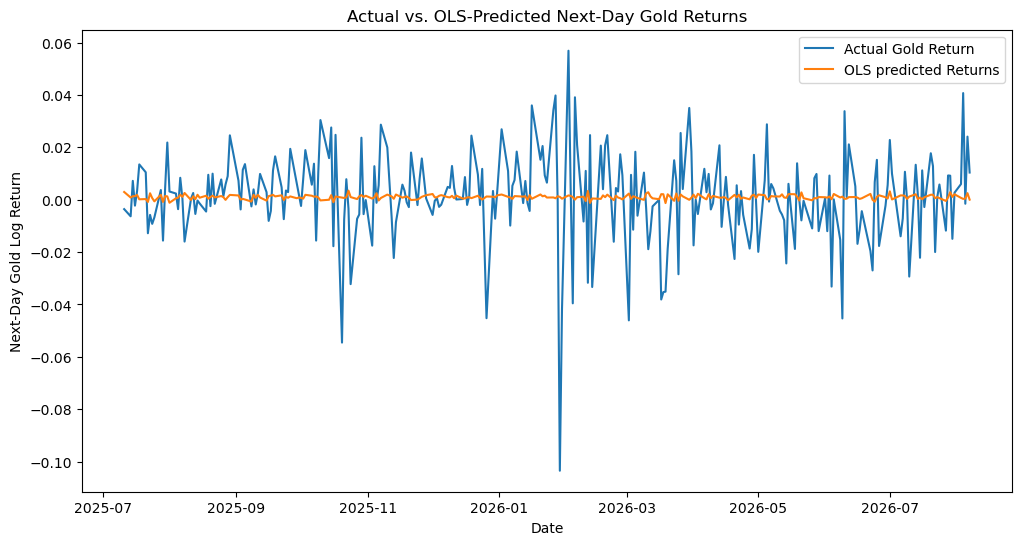

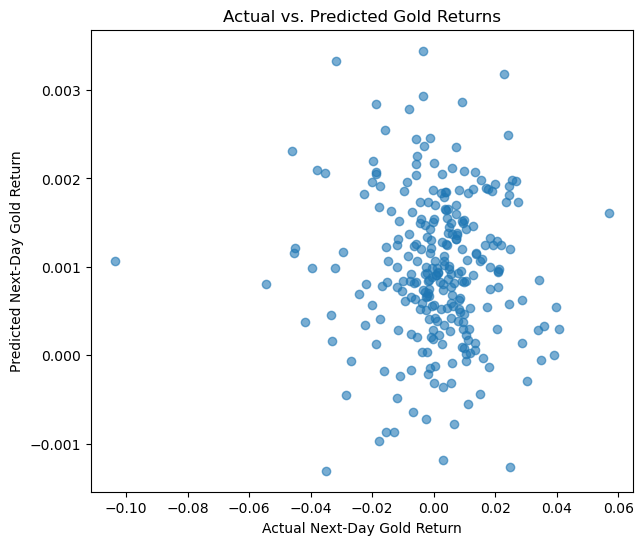

In [38]:
plt.figure(figsize=(12,6))
plt.plot(
    y_test.index,
    y_test,
    label="Actual Gold Return"
)
plt.plot(
    y_test.index,
    y_prediction,
    label = "OLS predicted Returns" 
)
plt.xlabel("Date")
plt.ylabel("Next-Day Gold Log Return")
plt.title("Actual vs. OLS-Predicted Next-Day Gold Returns")
plt.legend()

plt.show()

plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_prediction, alpha=0.6)

plt.xlabel("Actual Next-Day Gold Return")
plt.ylabel("Predicted Next-Day Gold Return")
plt.title("Actual vs. Predicted Gold Returns")

plt.show()